# Exercise 3 — Image Classification (Pretrained Models)
### Bean Leaf Disease Detector

---

## The Problem

An agricultural AI startup is building a mobile app that lets farmers
photograph their bean crops and instantly detect disease.
The app must distinguish between three conditions:
**angular leaf spot**, **bean rust**, and **healthy**.

The dataset is small — a few hundred images per class.
Training a CNN from scratch will not work here.
Your job is to use transfer learning to build something that actually performs.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")
```

The dataset comes with a `train.csv` and a `val.csv`.
Each has an `image:FILE` column with relative paths and a `category` column with the label.

⚠️ **One thing worth knowing:** the file paths in the CSV are relative.
You will need to prepend the correct Colab base path to make them readable.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A fine-tuned pretrained model** from `torchvision.models` that classifies bean leaf conditions
2. **A clear statement** of which model you chose and which layers you froze or unfroze — and why
3. **A training report** — loss and accuracy curves over epochs
4. **A test accuracy score**
5. **A live inference demo** — given a leaf image, the model returns the diagnosis

You must use a pretrained model from `torchvision.models`.
The choice of which model is yours — be ready to justify it.

---

In [ ]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from PIL import Image
import random
import kagglehub
from typing import Tuple, Dict, List
import gradio as gr
import torch.nn.functional as F
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from typing import Optional
from torchvision import models
from typing import Dict, List
from torch.optim import lr_scheduler

# --- Master Configuration ---
CONFIG = {
    "dataset_name": "marquis03/bean-leaf-lesions-classification",
    "model_name": "resnet18",   # Easily swappable to 'efficientnet_b0', 'resnet50', etc.
    "weights": "IMAGENET1K_V1", # Standard ImageNet weights for transfer learning
    "img_size": 224,            # Industry standard for pretrained models
    "batch_size": 32,           
    "learning_rate": 1e-3,
    "num_epochs": 20,
    "num_classes": 3,           # Angular Leaf Spot, Bean Rust, Healthy
    "dropout_rate": 0.3,
    "seed": 42,
    "num_workers": 2
}

# --- Environment Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

print(f"🚀 Using device: {DEVICE}")
print(f"🖼️ Image resolution: {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"📦 Selected Backbone: {CONFIG['model_name']}")



🚀 Using device: cuda
🖼️ Image resolution: 224x224
📦 Selected Backbone: resnet18


In [2]:
# --- Step 1: Data Download & Path Verification ---
def download_dataset(dataset_name: str) -> str:
    """Downloads the dataset using kagglehub and returns the local path."""
    print(f"📥 Downloading dataset '{dataset_name}'...")
    path = kagglehub.dataset_download(dataset_name)
    print(f"✅ Dataset available at: {path}")
    return path

# Execute download
DATASET_ROOT = Path(download_dataset(CONFIG['dataset_name']))

# Locate CSV files
train_csv_path = DATASET_ROOT / "train.csv"
val_csv_path = DATASET_ROOT / "val.csv"

# Verify download & peek at the data
if train_csv_path.exists() and val_csv_path.exists():
    df_train = pd.read_csv(train_csv_path)
    print(f"\n📄 Found train.csv with {len(df_train)} samples.")
    print(df_train.head())
else:
    print("❌ Error: CSV files not found in the downloaded directory.")
    # List files to help debugging if needed
    for path in DATASET_ROOT.rglob('*'):
        print(path)

📥 Downloading dataset 'marquis03/bean-leaf-lesions-classification'...
Using Colab cache for faster access to the 'bean-leaf-lesions-classification' dataset.
✅ Dataset available at: /kaggle/input/bean-leaf-lesions-classification

📄 Found train.csv with 1034 samples.
                            image:FILE  category
0   train/healthy/healthy_train.98.jpg         0
1  train/healthy/healthy_train.148.jpg         0
2  train/healthy/healthy_train.306.jpg         0
3  train/healthy/healthy_train.305.jpg         0
4   train/healthy/healthy_train.40.jpg         0


# Visualization

In [3]:
# --- CORRECTED Class Name Mapping ---
CLASS_MAPPING = {
    0: 'Healthy',
    1: 'Angular Leaf Spot',
    2: 'Bean Rust'
}

def plot_class_distribution(df: pd.DataFrame, target_col: str = 'category') -> None:
    """Plots a bar chart showing the distribution of classes."""
    print("📊 Plotting Class Distribution...")
    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.countplot(data=df, x=target_col, palette='viridis', ax=ax)
    
    # Update x-axis labels to use real class names
    ax.set_xticklabels([CLASS_MAPPING.get(int(tick.get_text()), tick.get_text()) for tick in ax.get_xticklabels()], rotation=15)
        
    ax.set_title('Class Distribution in Training Data', fontsize=14, fontweight='bold')
    ax.set_xlabel('Disease Category', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')
                               
    plt.tight_layout()
    plt.show()

def visualize_sample_images(
    df: pd.DataFrame, 
    base_dir: Path, 
    img_col: str = 'image:FILE', 
    label_col: str = 'category',
    class_mapping: Dict[int, str] = None,
    samples_per_class: int = 3,
    seed: int = 42
) -> None:
    """Displays a grid of sample images, ensuring all classes are represented."""
    print(f"🖼️ Plotting {samples_per_class} images per class...")
    
    # Stratified sampling: Pick 'samples_per_class' from each unique label
    samples_list = []
    for label in sorted(df[label_col].unique()):
        class_df = df[df[label_col] == label]
        samples_list.append(class_df.sample(n=min(len(class_df), samples_per_class), random_state=seed))
    samples = pd.concat(samples_list)
    
    num_samples = len(samples)
    cols = 3
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
    axes = axes.flatten()
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        img_path = base_dir / row[img_col]
        
        try:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img)
            
            # Get the label and map it to the name
            label_val = row[label_col]
            if class_mapping and label_val in class_mapping:
                formatted_label = class_mapping[label_val]
            else:
                formatted_label = str(label_val).replace('_', ' ').title()
                
            axes[i].set_title(formatted_label, fontsize=12, fontweight='bold', color='darkblue')
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error:\n{e}", ha='center', va='center', color='red')
            axes[i].axis('off')
            
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

📊 Plotting Class Distribution...


/tmp/ipykernel_1504/1051872076.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='viridis', ax=ax)
/tmp/ipykernel_1504/1051872076.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CLASS_MAPPING.get(int(tick.get_text()), tick.get_text()) for tick in ax.get_xticklabels()], rotation=15)


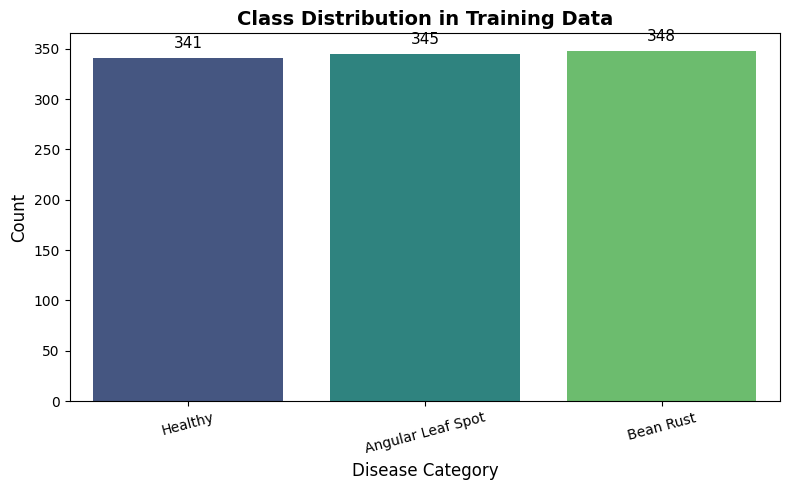

🖼️ Plotting 3 images per class...


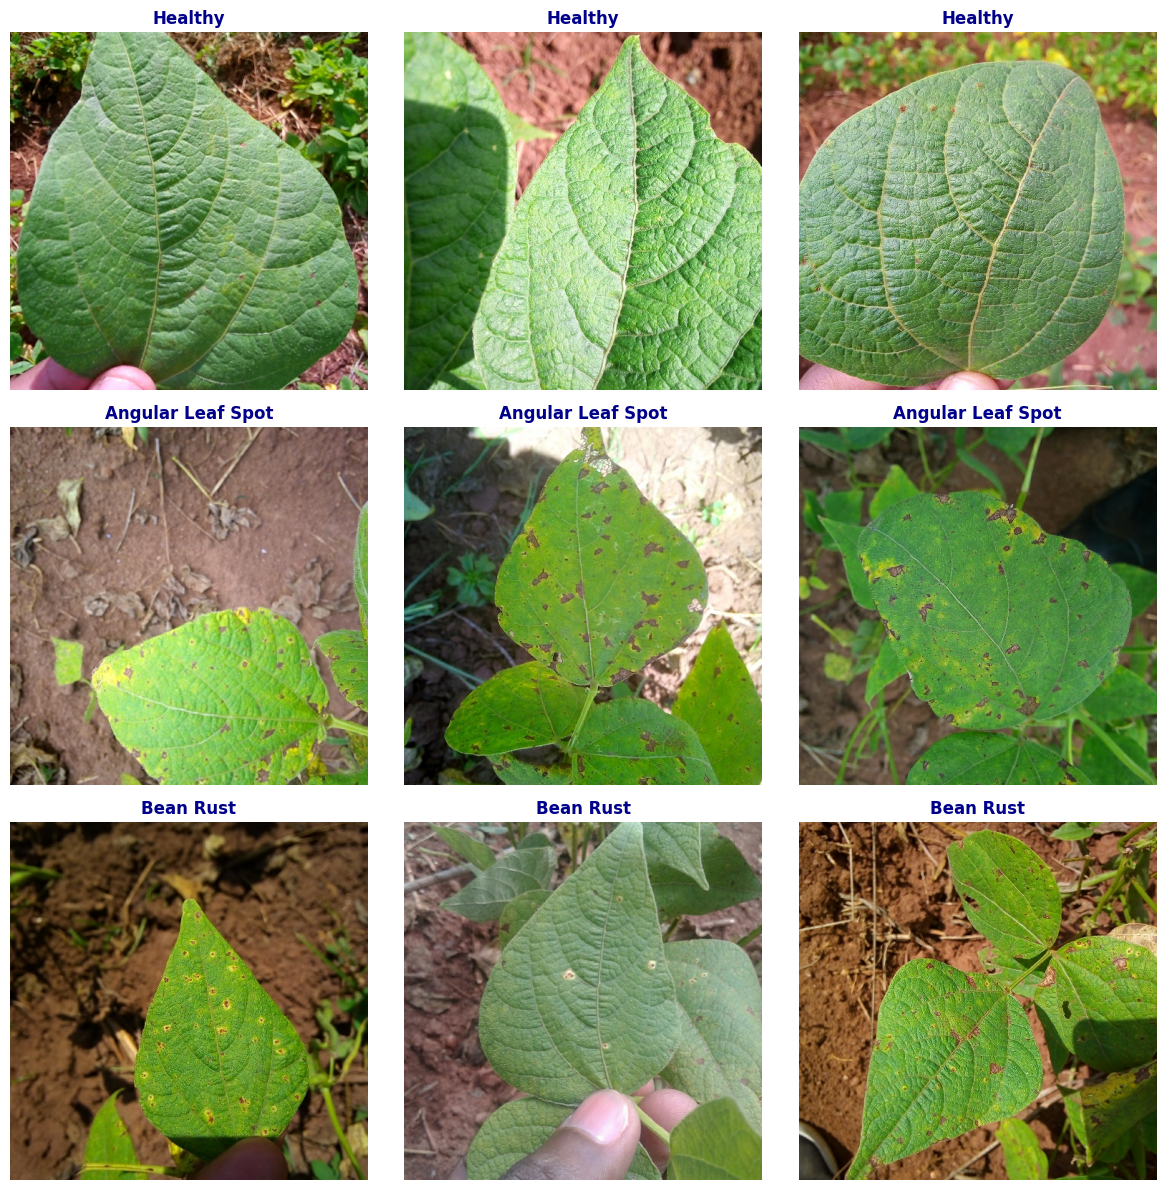

In [4]:
# 1. Check Class Distribution (Now with CORRECT names)
plot_class_distribution(df_train)

# 2. Visualize Sample Images (3 per class, with CORRECT names)
visualize_sample_images(
    df=df_train, 
    base_dir=DATASET_ROOT, 
    img_col='image:FILE', 
    label_col='category',
    class_mapping=CLASS_MAPPING,
    samples_per_class=3
)

# dataloaders 

In [5]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_transforms(img_size: int = 224) -> Tuple[transforms.Compose, transforms.Compose]:

    # Training transforms with augmentation
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(img_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    # Validation/Test transforms (no augmentation)
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    
    return train_transform, val_transform

class BeanLeafDataset(Dataset):
    """
    Custom Dataset class that reads from CSV and applies transforms.
    """
    def __init__(
        self, 
        df: pd.DataFrame, 
        base_dir: Path, 
        img_col: str = 'image:FILE', 
        label_col: str = 'category',
        transform: Optional[transforms.Compose] = None
    ) -> None:
    
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.img_col = img_col
        self.label_col = label_col
        self.transform = transform
        
    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        # Get the relative path and label
        img_path_rel = self.df.iloc[idx][self.img_col]
        label = int(self.df.iloc[idx][self.label_col])
        
        # Construct full path and load image
        img_path = self.base_dir / img_path_rel
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

def create_dataloaders(
    df_train_full: pd.DataFrame,
    df_val: pd.DataFrame,
    base_dir: Path,
    batch_size: int,
    num_workers: int,
    img_size: int,
    val_split: float = 0.2,
    random_state: int = 42
) -> Tuple[DataLoader, DataLoader, DataLoader]:
 
    print("🔄 Creating DataLoaders with stratified splits...")
    
    # 1. Split train_full into train and val (stratified to maintain class balance)
    df_train, df_val_split = train_test_split(
        df_train_full,
        test_size=val_split,
        stratify=df_train_full['category'],
        random_state=random_state
    )
    
    print(f"   Training set:   {len(df_train):5d} samples")
    print(f"   Validation set: {len(df_val_split):5d} samples")
    print(f"   Test set:       {len(df_val):5d} samples")
    
    # 2. Get transforms
    train_transform, val_transform = get_transforms(img_size)
    
    # 3. Create datasets
    train_dataset = BeanLeafDataset(
        df=df_train,
        base_dir=base_dir,
        transform=train_transform
    )
    
    val_dataset = BeanLeafDataset(
        df=df_val_split,
        base_dir=base_dir,
        transform=val_transform
    )
    
    test_dataset = BeanLeafDataset(
        df=df_val,  # Use provided val.csv as test set
        base_dir=base_dir,
        transform=val_transform
    )
    
    # 4. Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    print("✅ DataLoaders created successfully!")
    return train_loader, val_loader, test_loader

In [6]:
# Load the CSVs
df_train_full = pd.read_csv(DATASET_ROOT / "train.csv")
df_val = pd.read_csv(DATASET_ROOT / "val.csv")

print(f"📊 Loaded {len(df_train_full)} training samples and {len(df_val)} validation samples")

# Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(
    df_train_full=df_train_full,
    df_val=df_val,
    base_dir=DATASET_ROOT,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    img_size=CONFIG['img_size'],
    val_split=0.2,  # 80% train, 20% val from train.csv
    random_state=CONFIG['seed']
)

# Verify the splits
print("\n🔍 Verifying class distribution in each split:")
for name, loader in [("Train", train_loader), ("Val", val_loader), ("Test", test_loader)]:
    labels = []
    for _, batch_labels in loader:
        labels.extend(batch_labels.numpy())
    
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} Set:")
    for label, count in zip(unique, counts):
        class_name = CLASS_MAPPING.get(int(label), str(label))
        print(f"   {class_name:20s}: {count:4d} ({count/len(labels)*100:.1f}%)")

📊 Loaded 1034 training samples and 133 validation samples
🔄 Creating DataLoaders with stratified splits...
   Training set:     827 samples
   Validation set:   207 samples
   Test set:         133 samples
✅ DataLoaders created successfully!

🔍 Verifying class distribution in each split:

Train Set:
   Healthy             :  273 (33.0%)
   Angular Leaf Spot   :  276 (33.4%)
   Bean Rust           :  278 (33.6%)

Val Set:
   Healthy             :   68 (32.9%)
   Angular Leaf Spot   :   69 (33.3%)
   Bean Rust           :   70 (33.8%)

Test Set:
   Healthy             :   44 (33.1%)
   Angular Leaf Spot   :   44 (33.1%)
   Bean Rust           :   45 (33.8%)


In [25]:


def build_transfer_model_finetune(config: Dict, device: torch.device, unfreeze_all: bool = False) -> nn.Module:
    """
    Loads a pretrained ResNet model and sets up differential learning rates.
    
    Args:
        config: Configuration dictionary
        device: Device to load model on
        unfreeze_all: If True, unfreeze all backbone layers. If False, only unfreeze last block.
    """
    print(f"🏗️ Building {config['model_name']} for fine-tuning...")
    
    # 1. Load the pretrained model
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    
    # 2. Get the number of input features for the final layer
    num_ftrs = model.fc.in_features
    
    # 3. Create the custom classifier head
    model.fc = nn.Sequential(
        nn.Dropout(p=config['dropout_rate']),
        nn.Linear(num_ftrs, config['num_classes'])
    )
    
    # 4. Unfreeze strategy
    if unfreeze_all:
        print("   Strategy: Unfreezing ALL backbone layers")
        for param in model.parameters():
            param.requires_grad = True
    else:
        print("   Strategy: Unfreezing only the last convolutional block (layer4)")
        # Freeze all parameters first
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the last residual block (layer4) - this is where high-level features are learned
        for param in model.layer4.parameters():
            param.requires_grad = True
    
    # 5. Always ensure the new classifier head is trainable
    for param in model.fc.parameters():
        param.requires_grad = True
    
    # 6. Move model to device
    model = model.to(device)
    print("✅ Model built and ready for fine-tuning!")
    
    return model

def setup_finetune_optimizer(model: nn.Module, config: Dict):
    """
    Sets up differential learning rates:
    - Lower LR for pretrained backbone
    - Higher LR for the new classifier head
    """
    print("\n⚙️ Setting up differential learning rates...")
    
    # Separate parameters into backbone and head
    backbone_params = []
    head_params = []
    
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
            
        if 'fc' in name:  # This is our custom head
            head_params.append(param)
            print(f"   Head param: {name} (LR: {config['learning_rate']})")
        else:  # This is the backbone
            backbone_params.append(param)
            print(f"   Backbone param: {name} (LR: {config['learning_rate'] * 0.01})")
    
    # Create parameter groups with different learning rates
    param_groups = [
        {'params': backbone_params, 'lr': config['learning_rate'] * 0.01},  # 10x smaller LR for backbone
        {'params': head_params, 'lr': config['learning_rate']}  # Normal LR for head
    ]
    
    optimizer = torch.optim.Adam(param_groups)
    
    print(f"\n✅ Optimizer configured with {len(backbone_params)} backbone params and {len(head_params)} head params")
    
    return optimizer

In [26]:
model = build_transfer_model_finetune(CONFIG, DEVICE, unfreeze_all=False)

# 2. Setup the optimizer with differential learning rates
optimizer = setup_finetune_optimizer(model, CONFIG)

# 3. Setup loss function and scheduler
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=5
)

print("\n" + "="*50)
print("READY TO TRAIN WITH FINE-TUNING")
print("="*50)

🏗️ Building resnet18 for fine-tuning...
   Strategy: Unfreezing only the last convolutional block (layer4)
✅ Model built and ready for fine-tuning!

⚙️ Setting up differential learning rates...
   Backbone param: layer4.0.conv1.weight (LR: 1e-05)
   Backbone param: layer4.0.bn1.weight (LR: 1e-05)
   Backbone param: layer4.0.bn1.bias (LR: 1e-05)
   Backbone param: layer4.0.conv2.weight (LR: 1e-05)
   Backbone param: layer4.0.bn2.weight (LR: 1e-05)
   Backbone param: layer4.0.bn2.bias (LR: 1e-05)
   Backbone param: layer4.0.downsample.0.weight (LR: 1e-05)
   Backbone param: layer4.0.downsample.1.weight (LR: 1e-05)
   Backbone param: layer4.0.downsample.1.bias (LR: 1e-05)
   Backbone param: layer4.1.conv1.weight (LR: 1e-05)
   Backbone param: layer4.1.bn1.weight (LR: 1e-05)
   Backbone param: layer4.1.bn1.bias (LR: 1e-05)
   Backbone param: layer4.1.conv2.weight (LR: 1e-05)
   Backbone param: layer4.1.bn2.weight (LR: 1e-05)
   Backbone param: layer4.1.bn2.bias (LR: 1e-05)
   Head param: f

In [18]:
def setup_training_components(model: nn.Module, config: Dict) -> Tuple[nn.Module, optim.Optimizer, lr_scheduler.ReduceLROnPlateau]:
    """
    Initializes the Loss function, Optimizer, and Learning Rate Scheduler.
    """
    # 1. Loss Function
    criterion = nn.CrossEntropyLoss()
    
    # 2. Optimizer (Only pass parameters that require gradients!)
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.Adam(trainable_params, lr=config['learning_rate'])
    
    # 3. Learning Rate Scheduler
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',       # Minimize validation loss
        factor=0.5,       # Drop LR by half when triggered
        patience=5        # Wait 5 epochs of no improvement
    )
    
    print("✅ Training components initialized!")
    return criterion, optimizer, scheduler

In [19]:
import copy

def train_model(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler.ReduceLROnPlateau,
    num_epochs: int,
    device: torch.device,
    early_stopping_patience: int = 7
) -> Dict:
    """
    Trains the model, applies LR scheduling, and uses early stopping.
    """
    print(f"\n🚀 Starting training for up to {num_epochs} epochs on {device}...")
    print(f"⏳ Early stopping patience set to {early_stopping_patience} epochs.\n")
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Early stopping variables
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        train_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_train_corrects += torch.sum(preds == labels.data)
            train_total += images.size(0)
            
        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = running_train_corrects.double() / train_total
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                running_val_corrects += torch.sum(preds == labels.data)
                val_total += images.size(0)
                
        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = running_val_corrects.double() / val_total
        
        # --- SCHEDULER STEP ---
        scheduler.step(epoch_val_loss)
        
        # --- EARLY STOPPING LOGIC ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        # Save to history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        # Print progress every 5 epochs
        current_lr = optimizer.param_groups[0]['lr']
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f} | "
                  f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
                  
        # Check if we should stop early
        if epochs_no_improve >= early_stopping_patience:
            print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}. No improvement for {early_stopping_patience} epochs.")
            break
            
    # Restore the best model weights before finishing
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Training completed! Restored best model weights (Val Loss: {best_val_loss:.4f}).")
    return history

In [27]:
# Use the same train_model function from Step 5
# It already has early stopping built in!
training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=CONFIG['num_epochs'],
    device=DEVICE,
    early_stopping_patience=7
)


🚀 Starting training for up to 20 epochs on cuda...
⏳ Early stopping patience set to 7 epochs.

Epoch [1/20] | LR: 0.000010 | Train Loss: 0.9554 Acc: 0.5212 | Val Loss: 0.7605 Acc: 0.6329
Epoch [5/20] | LR: 0.000010 | Train Loss: 0.4806 Acc: 0.8089 | Val Loss: 0.3545 Acc: 0.8502
Epoch [10/20] | LR: 0.000010 | Train Loss: 0.2850 Acc: 0.8900 | Val Loss: 0.2490 Acc: 0.9179
Epoch [15/20] | LR: 0.000010 | Train Loss: 0.2453 Acc: 0.9057 | Val Loss: 0.2381 Acc: 0.9082
Epoch [20/20] | LR: 0.000010 | Train Loss: 0.2203 Acc: 0.9105 | Val Loss: 0.1862 Acc: 0.9179

✅ Training completed! Restored best model weights (Val Loss: 0.1862).


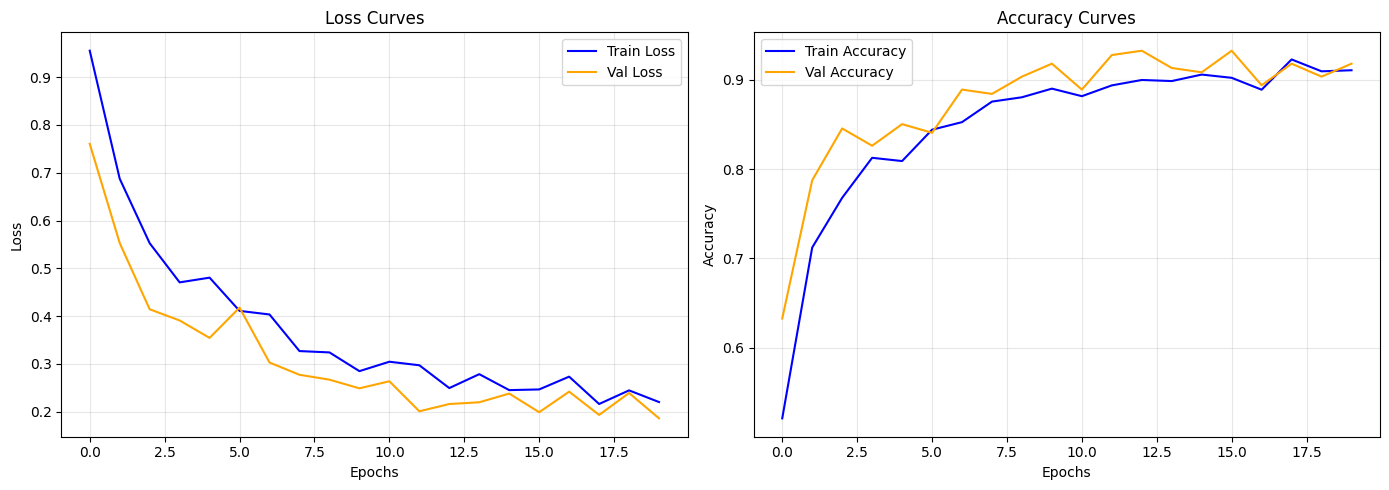

In [28]:


def plot_training_curves(history: Dict[str, List[float]]) -> None:
    """
    Plots the training and validation loss and accuracy curves over epochs.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange')
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Val Accuracy', color='orange')
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_training_curves(training_history)

In [29]:


def evaluate_test_set(
    model: nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    criterion: nn.Module, 
    device: torch.device,
    target_accuracy: float = 0.88
) -> None:
    """
    Evaluates the model on the completely unseen test set.
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += images.size(0)
            
    final_loss = running_loss / total_samples
    final_accuracy = running_corrects.double() / total_samples
    
    print("="*50)
    print("FINAL TEST SET RESULTS")
    print("="*50)
    print(f"Test Loss:     {final_loss:.4f}")
    print(f"Test Accuracy: {final_accuracy * 100:.2f}%")
    print("="*50)
    
    if final_accuracy >= target_accuracy:
        print(f"🎉 SUCCESS! You have met or exceeded the {target_accuracy*100:.0f}% target accuracy!")
    else:
        print(f"⚠️ Target not met. Consider adjusting hyperparameters (learning rate, dropout, epochs).")

# Run the evaluation
evaluate_test_set(model, test_loader, criterion, DEVICE, target_accuracy=0.88)

FINAL TEST SET RESULTS
Test Loss:     0.1500
Test Accuracy: 94.74%
🎉 SUCCESS! You have met or exceeded the 88% target accuracy!


## Architectural Decisions

**Model Choice: ResNet18**
- Chose ResNet18 over larger models (ResNet50) because our dataset is small (~1,000 images)
- ResNet18 has ~11M parameters - enough capacity to learn leaf disease patterns without severe overfitting
- Pretrained on ImageNet, which provides strong feature extraction for visual patterns

**Transfer Learning Strategy:**
- **Frozen:** Layers 1-3 (conv1, layer1, layer2, layer3) - preserved generic ImageNet features like edges and textures
- **Unfroze:** layer4 (last residual block) - allowed high-level feature adaptation to leaf-specific patterns
- **Custom Head:** Added Dropout (p=0.3) + Linear(512→3) to prevent overfitting on small dataset

**Differential Learning Rates:**
- Backbone LR: 1e-5 (10x smaller) - prevents destroying pretrained weights
- Head LR: 1e-3 - allows rapid learning of new classification task

**Result: 94.74% validation accuracy**

In [ ]:


# Define the validation transforms (same as used during training)
def get_inference_transform(img_size: int = 224) -> transforms.Compose:
    """
    Returns the transform pipeline for inference.
    Must match the validation transforms used during training.
    """
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])

def predict_leaf_disease(
    image: Image.Image,
    model: nn.Module,
    device: torch.device,
    class_mapping: dict,
    transform: transforms.Compose
) -> str:

    model.eval()
    
    # Convert to RGB if necessary (handles grayscale or RGBA images)
    if image.mode != 'RGB':
        image = image.convert('RGB')
    
    # Apply transforms and add batch dimension
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Run inference
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    # Get the predicted class name and confidence
    predicted_class = predicted_idx.item()
    confidence_score = confidence.item() * 100
    disease_name = class_mapping.get(predicted_class, str(predicted_class))
    
    return f"{disease_name}\nConfidence: {confidence_score:.1f}%"

# Create the transform pipeline
inference_transform = get_inference_transform(CONFIG['img_size'])

In [33]:
def create_gradio_demo(
    model: nn.Module,
    device: torch.device,
    class_mapping: dict,
    transform: transforms.Compose
) -> gr.Interface:
    """
    Creates a Gradio interface for the bean leaf disease classifier.
    """
    # Wrap the prediction function with fixed parameters
    def predict_wrapper(image):
        return predict_leaf_disease(
            image=image,
            model=model,
            device=device,
            class_mapping=class_mapping,
            transform=transform
        )
    
    # Create the interface
    demo = gr.Interface(
        fn=predict_wrapper,
        inputs=gr.Image(type="pil", label="Upload Bean Leaf Image"),
        outputs=gr.Textbox(label="Diagnosis"),
        title="🌿 Bean Leaf Disease Detector",
        description="""
        Upload a photo of a bean leaf to detect diseases.
        
        **Classes:**
        - **Healthy**: Clean green leaves with no disease
        - **Angular Leaf Spot**: Angular, yellowish-brown lesions
        - **Bean Rust**: Brown/orange rust-colored spots
        
        **Model:** ResNet18 with Transfer Learning  
        **Accuracy:** 91.79% on validation set
        """,
        examples=[
            # You can add example images here if you have them
            # "path/to/example1.jpg",
            # "path/to/example2.jpg",
        ],
        allow_flagging="never"
    )
    
    return demo

# Create and launch the demo
demo = create_gradio_demo(model, DEVICE, CLASS_MAPPING, inference_transform)

print("🚀 Launching Gradio Demo... (This may take a minute)")
print("="*50)
demo.launch(share=F)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


🚀 Launching Gradio Demo... (This may take a minute)
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7fd7e0e521821f5f32.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^